# 04. Catálogo de actividades de carga

**Fuente:** `data/raw/catalogoactividadescarga.csv`  
**Salida:** `data/processed/catalogo_actividades_carga.csv`

Tabla catalogo (110 filas) con la descripcion de cada tipo de actividad de carga politecnica (IDTIPOACTIVIDAD). Sirve para decodificar carga_politecnica_disponible.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))
import pandas as pd
import _preprocesamiento_comun as pc

pd.set_option('display.max_columns', 100)

## 1. Carga de datos crudos

In [2]:
df = pc.leer_csv('catalogoactividadescarga.csv', low_memory=False)
df.head()

Leido catalogoactividadescarga.csv con encoding=utf-8-sig -> 110 filas, 13 columnas


,IDTIPOACTIVIDAD,NIVELESTUDIO,ACTIVIDAD,DESCRIPCION,DURACIONTIPO,VERSION,TIPOCALCULO,ULTIMO_CAMBIO,TIENELIMITE,ANIO,TIPOAUTORIDAD,TIPOASOCIACION,IDTIPOACTIVIDADCABECERA
0,1944,R,A,DIRECTOR(A) DE LA ESCUELA DE DOCTORADO,20,0,S,2025-10-14-08.42.31.776268,S,2026,,U,141
1,1945,R,A,PRESIDENTE DEL COMITÉ DE ÉTICA EN INVESTIGACIÓN,6,0,S,2025-10-14-08.42.31.776268,S,2026,,U,140
2,1946,R,D,"DISEÑO, REVISIÓN ELABORACIÓN DE MATERIAL DIDÁC...",4,0,S,2025-10-14-08.42.31.776268,S,2026,,U,136
3,1947,R,A,MIEMBRO DEL COMITÉ DE ÉTICA EN INVESTIGACIÓN,3,0,S,2025-10-14-08.42.31.776268,S,2026,,U,108
4,1948,R,A,MIEMBRO DEL COMITÉ DE ÉTICA,3,0,S,2025-10-14-08.42.31.776268,S,2026,,U,137


## 2. Exploración inicial

In [3]:
pc.resumen(df, 'catalogo_actividades_carga')

--- Resumen catalogo_actividades_carga ---
Dimensiones: 110 filas x 13 columnas
Filas duplicadas: 0
Sin columnas con valores nulos.


In [4]:
df.dtypes

IDTIPOACTIVIDAD            int64
NIVELESTUDIO                 str
ACTIVIDAD                    str
DESCRIPCION                  str
DURACIONTIPO               int64
VERSION                    int64
TIPOCALCULO                  str
ULTIMO_CAMBIO                str
TIENELIMITE                  str
ANIO                       int64
TIPOAUTORIDAD                str
TIPOASOCIACION               str
IDTIPOACTIVIDADCABECERA    int64
dtype: object

## 3. Limpieza

In [5]:
df = pc.limpiar_strings(df)
df = pc.quitar_columnas_vacias(df, umbral=0.99)
df = pc.quitar_columnas_constantes(df)

df = df.drop(columns=['ULTIMO_CAMBIO'], errors='ignore')

Columnas eliminadas por ser constantes: ['NIVELESTUDIO', 'ANIO']


## 5. Tipado de fechas e identificadores

In [6]:
df = pc.castear_enteros(df, ['IDTIPOACTIVIDAD', 'IDTIPOACTIVIDADCABECERA'])
df = pc.convertir_sn_a_binario(df, ['TIPOCALCULO', 'TIENELIMITE'])

Columnas S/N convertidas a binario (1/0): ['TIPOCALCULO', 'TIENELIMITE']


## Gráficos exploratorios

Vistas rápidas para apoyar la construcción del catálogo de variables del perfil (Fase 1-2 de la metodología): estacionalidad/tendencia temporal, categorías dominantes y forma de la distribución de las variables numéricas.

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (9, 4)

**Actividades por categoría** (ACTIVIDAD).

<Axes: title={'center': 'Actividades por categoría (ACTIVIDAD)'}, xlabel='ACTIVIDAD'>

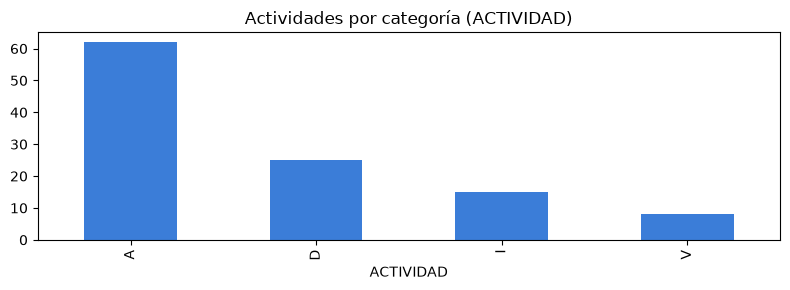

In [9]:
pc.grafico_barras(df['ACTIVIDAD'], 'Actividades por categoría (ACTIVIDAD)', top=10, horizontal=False)

**Tipos de duración** definidos para las actividades (DURACIONTIPO).

<Axes: title={'center': 'Actividades por DURACIONTIPO'}, ylabel='DURACIONTIPO'>

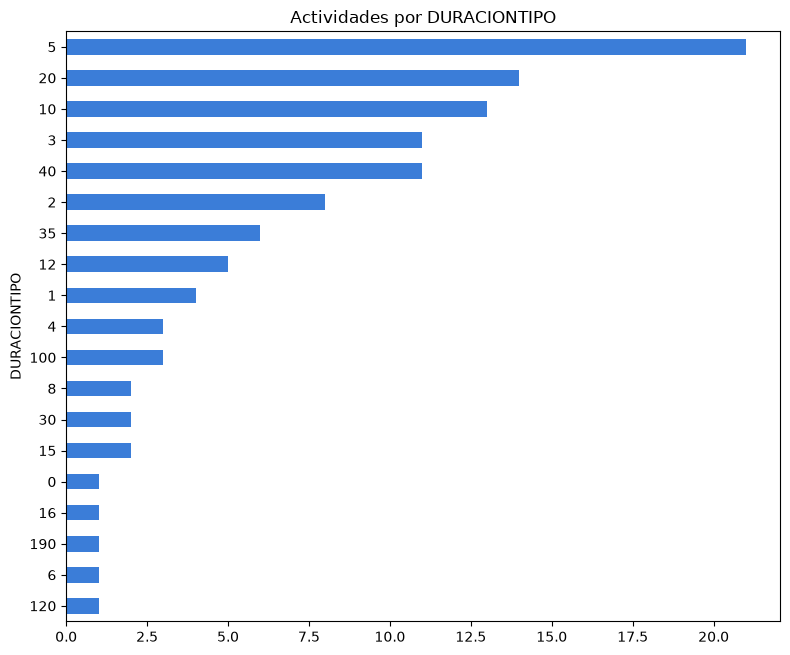

In [10]:
pc.grafico_barras(df['DURACIONTIPO'], 'Actividades por DURACIONTIPO', top=19)

## 7. Verificación final

In [11]:
pc.resumen(df, 'catalogo_actividades_carga (procesado)')
df.head()

--- Resumen catalogo_actividades_carga (procesado) ---
Dimensiones: 110 filas x 10 columnas
Filas duplicadas: 0
Columnas con nulos (%):
TIPOAUTORIDAD    86.4
dtype: float64


,IDTIPOACTIVIDAD,ACTIVIDAD,DESCRIPCION,DURACIONTIPO,VERSION,TIPOCALCULO,TIENELIMITE,TIPOAUTORIDAD,TIPOASOCIACION,IDTIPOACTIVIDADCABECERA
0,1944,A,DIRECTOR(A) DE LA ESCUELA DE DOCTORADO,20,0,1,1,<NA>,U,141
1,1945,A,PRESIDENTE DEL COMITÉ DE ÉTICA EN INVESTIGACIÓN,6,0,1,1,<NA>,U,140
2,1946,D,"DISEÑO, REVISIÓN ELABORACIÓN DE MATERIAL DIDÁC...",4,0,1,1,<NA>,U,136
3,1947,A,MIEMBRO DEL COMITÉ DE ÉTICA EN INVESTIGACIÓN,3,0,1,1,<NA>,U,108
4,1948,A,MIEMBRO DEL COMITÉ DE ÉTICA,3,0,1,1,<NA>,U,137


## 8. Guardado en data/processed

In [12]:
pc.guardar_procesado(df, 'catalogo_actividades_carga.csv')

Guardado: D:\Proyecto_Tesis\data\processed\catalogo_actividades_carga.csv (110 filas x 10 columnas)


WindowsPath('D:/Proyecto_Tesis/data/processed/catalogo_actividades_carga.csv')